### Student Name: Abin Baby
### Student Id: 224640656

## Loading and understanding dataset

In [8]:
import pandas as pd
df = pd.read_csv("phoenix_synthetic_dataset_2024.csv")
print(df.head())
print(df.info())
print(df.describe())

         date           region  season disaster_type hazard_level  \
0  01-01-2024       Shepparton  Summer           NaN          Low   
1  02-01-2024  Melbourne Metro  Summer           NaN          Low   
2  03-01-2024  Melbourne Metro  Summer           NaN          Low   
3  04-01-2024       Shepparton  Summer           NaN          Low   
4  05-01-2024         Ballarat  Summer           NaN       Medium   

   temperature_c  rainfall_mm  wind_kmh  cyber_incidents  phishing_reports  \
0           32.1          2.5      18.1                4                 4   
1           30.3          0.5      28.0                5                 3   
2           33.1          3.2      18.9               20                12   
3           31.9          0.4      19.5                3                 5   
4           34.0          2.3      24.4                2                 5   

   misinformation_reports  vulnerability_alerts  donation_scam_reports  \
0                       2                 

## Basic exploration

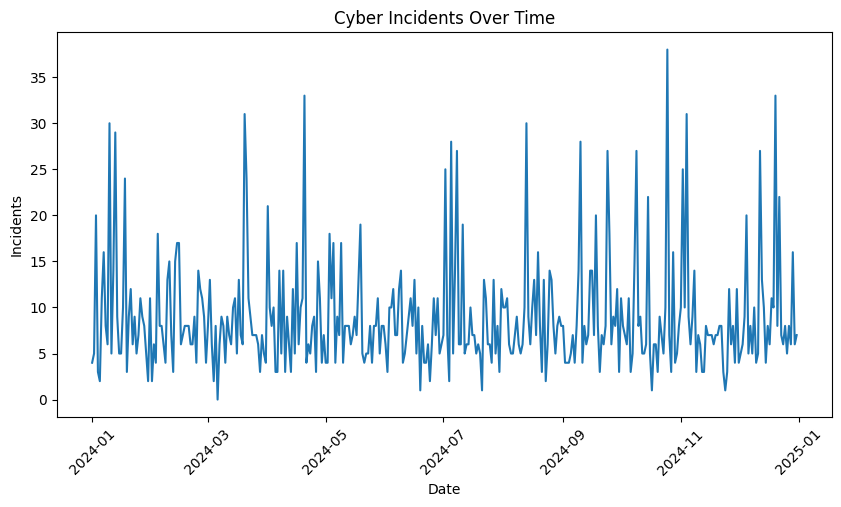

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
# Convert date correctly
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Plot cyber incidents over time
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['cyber_incidents'])
plt.xticks(rotation=45)
plt.title("Cyber Incidents Over Time")
plt.xlabel("Date")
plt.ylabel("Incidents")
plt.show()

## Relationship between hazard and cyber incidents

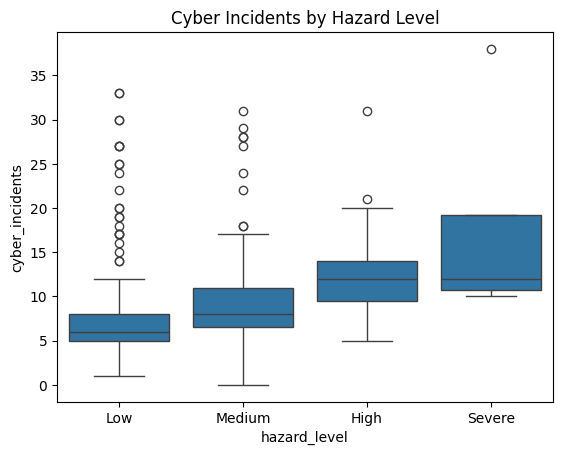

In [10]:
import seaborn as sns
plt.figure()
sns.boxplot(x='hazard_level', y='cyber_incidents', data=df)
plt.title("Cyber Incidents by Hazard Level")
plt.show()

## Correlation analysis

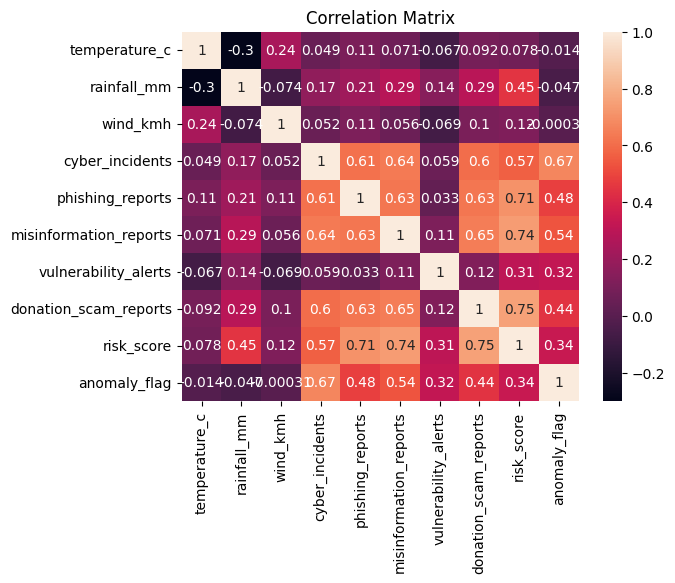

In [5]:
plt.figure()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Anomaly Detection

In [6]:
from sklearn.ensemble import IsolationForest

features = df[['cyber_incidents', 'phishing_reports', 'misinformation_reports']]

model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(features)

# Show anomalies
anomalies = df[df['anomaly'] == -1]
print(anomalies)

          date           region  season disaster_type hazard_level  \
12  2024-01-13        Gippsland  Summer           NaN       Medium   
34  2024-02-04         Ballarat  Summer           NaN       Medium   
79  2024-03-20         Ballarat  Autumn         Storm         High   
91  2024-04-01       Shepparton  Autumn         Flood         High   
106 2024-04-16  Melbourne Metro  Autumn           NaN          Low   
110 2024-04-20          Bendigo  Autumn           NaN          Low   
167 2024-06-16  Melbourne Metro  Winter         Flood         High   
183 2024-07-02        Gippsland  Winter           NaN          Low   
186 2024-07-05          Geelong  Winter           NaN       Medium   
192 2024-07-11        Gippsland  Winter           NaN          Low   
208 2024-07-27        Gippsland  Winter         Flood       Severe   
253 2024-09-10  Melbourne Metro  Spring           NaN       Medium   
298 2024-10-25          Bendigo  Spring         Flood       Severe   
308 2024-11-04  Melb

## Visualise anomalies

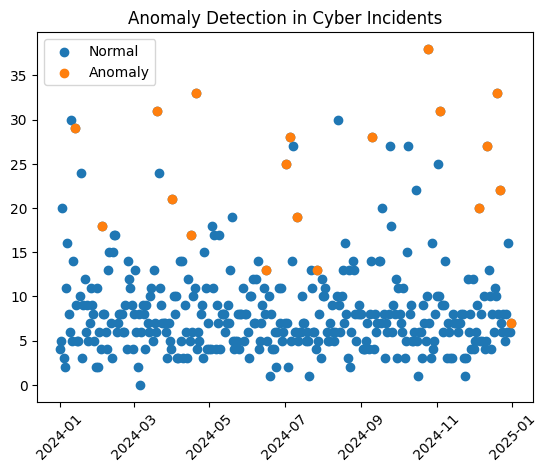

In [7]:
plt.figure()
plt.scatter(df['date'], df['cyber_incidents'], label='Normal')
plt.scatter(anomalies['date'], anomalies['cyber_incidents'], label='Anomaly')
plt.legend()
plt.title("Anomaly Detection in Cyber Incidents")
plt.xticks(rotation=45)
plt.show()